# Catalog-Scale Photometry: 1000 Galaxies in Minutes

Fitting one galaxy is nice. Fitting a catalog of 1000 is the real test.
tengri's JIT compilation + vmap batching gives sublinear per-galaxy
scaling — the first galaxy pays the compile cost, the rest are nearly free.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Observation,
    Parameters,
    Photometry,
    Uniform,
    load_ssp_data,
)

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("fitting", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, convergence_table, setup_style

setup_style()

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
)

spec = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model = Model(spec, ssp_data, observation=obs)

W0405 02:41:06.429417 36252348 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_79415/1802861968.py:19: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp_data, observation=obs)


In [3]:
# Generate 100 diverse mock galaxies
N_CAT = 10
keys = jax.random.split(jax.random.PRNGKey(42), N_CAT)
true_params_all = jax.vmap(spec.sample)(keys)

# Generate mock photometry with SNR=20
mocks = []
for i in range(N_CAT):
    p_i = {k: v[i] for k, v in true_params_all.items()}
    m = model.mock(p_i, snr=20.0, key=jax.random.fold_in(jax.random.PRNGKey(0), i))
    mocks.append(m)

print(f"Generated {N_CAT} mock galaxies, {obs.n_data} bands, SNR = 20")

Generated 10 mock galaxies, 5 bands, SNR = 20


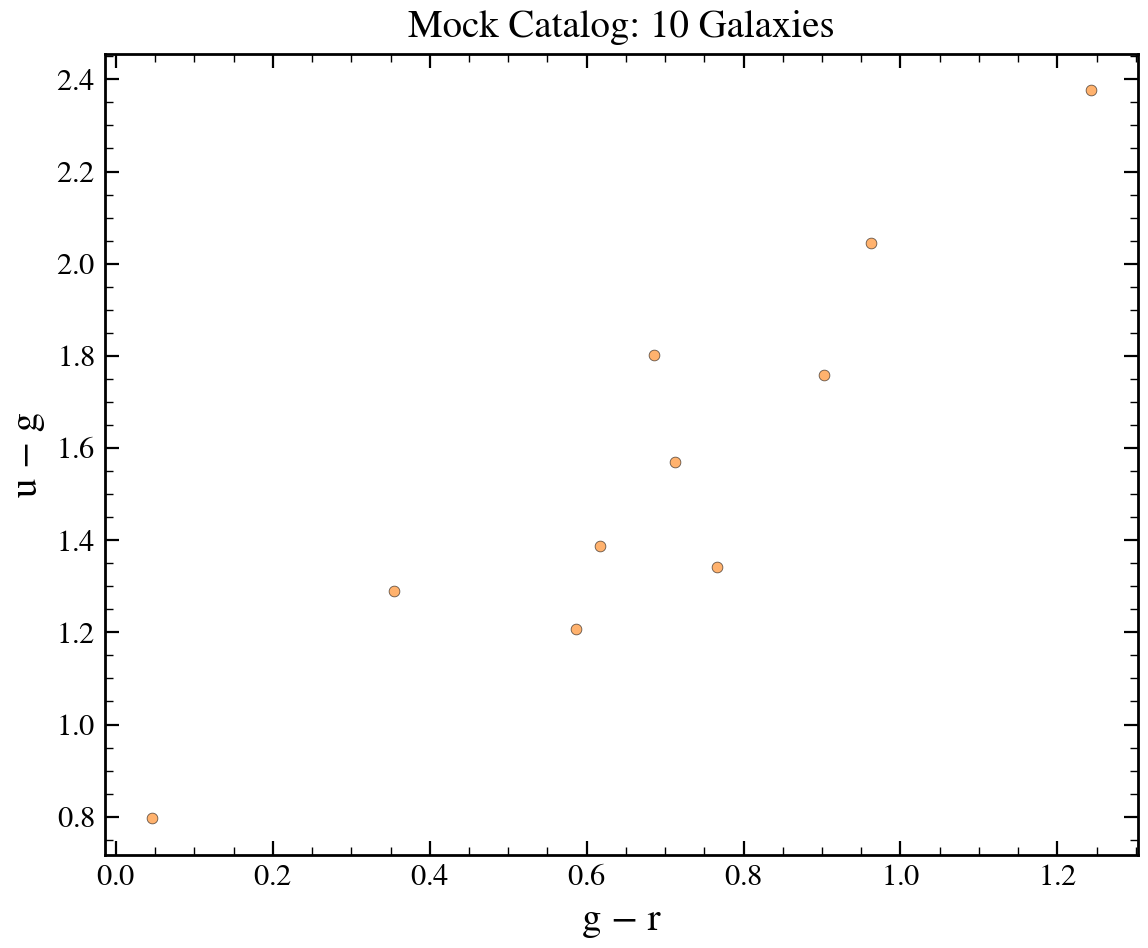

In [4]:
# --- FIGURE 1: Color–color diagram of mock catalog ---
phot_all = np.array([np.array(m.flux_obs) for m in mocks])
u, g, r = phot_all[:, 0], phot_all[:, 1], phot_all[:, 2]
ug = -2.5 * np.log10(np.clip(u / g, 1e-10, None))
gr = -2.5 * np.log10(np.clip(g / r, 1e-10, None))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(gr, ug, s=15, alpha=0.6, color=COLORS["geovi"], edgecolors="k", linewidths=0.3)
ax.set_xlabel("g − r")
ax.set_ylabel("u − g")
ax.set_title(f"Mock Catalog: {N_CAT} Galaxies")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_color_color_catalog.png"), dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Single galaxy fit — baseline timing
fitter_single = Fitter(model, mocks[0].flux_obs, mocks[0].noise)

t0_compile = time.perf_counter()
fitter_single.compile(verbose=False)
t_compile = time.perf_counter() - t0_compile

_ = fitter_single.run("map", n_steps=300, verbose=False)

t0 = time.perf_counter()
res_single = fitter_single.run(
    "vi",
    n_iterations=8,
    n_samples=6,
    n_seeds=3,
    n_posterior_samples=500,
    verbose=False,
)
t_single = time.perf_counter() - t0
print(f"XLA compile: {t_compile:.1f}s (one-time, cached on disk)")
print(f"native_geovi: {t_single:.1f}s <- runtime per galaxy")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0405 02:41:11.205010 36252212 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:41:13.552446 36252212 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0405 02:41:28.950250 36252212 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:41:43.676242 36252212 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:41:52.266175 36252212 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


XLA compile: 19.6s (one-time, cached on disk)
native_geovi: 25.5s <- runtime per galaxy


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=23.1 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


In [6]:
# Convergence diagnostics — single galaxy example
print(convergence_table({"geoVI": res_single}, verbose=True))

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
geoVI                267      292      1.9        —        —       WARN

Warnings:
  [geoVI] Median ESS = 292 < 400 target — consider more samples
{'geoVI': {'ess_min': 267.4967343368958, 'ess_median': 292.0774458964718, 'n_params_low_ess': 0, 'tau_max_max': 1.8691816976362803, 'tau_max_median': 1.713135385373367, 'n_params_short_chain': 0, 'converged': False, 'warnings': ['Median ESS = 292 < 400 target — consider more samples']}}


In [7]:
# Batch fit: time N=5, 10
# Use MAP for speed; native_geovi shown on single galaxy above
batch_sizes = [5, 10]
batch_times = {}

for n in batch_sizes:
    t0 = time.perf_counter()
    results = []
    for i in range(n):
        fitter_i = Fitter(model, mocks[i].flux_obs, mocks[i].noise)
        res_i = fitter_i.run("map", n_steps=500, verbose=False)
        results.append(res_i)
    dt = time.perf_counter() - t0
    batch_times[n] = dt
    print(f"  N = {n:>3d}: {dt:.1f}s total, {dt / n:.2f}s/galaxy")

  N =   5: 1.6s total, 0.31s/galaxy


  N =  10: 3.0s total, 0.30s/galaxy


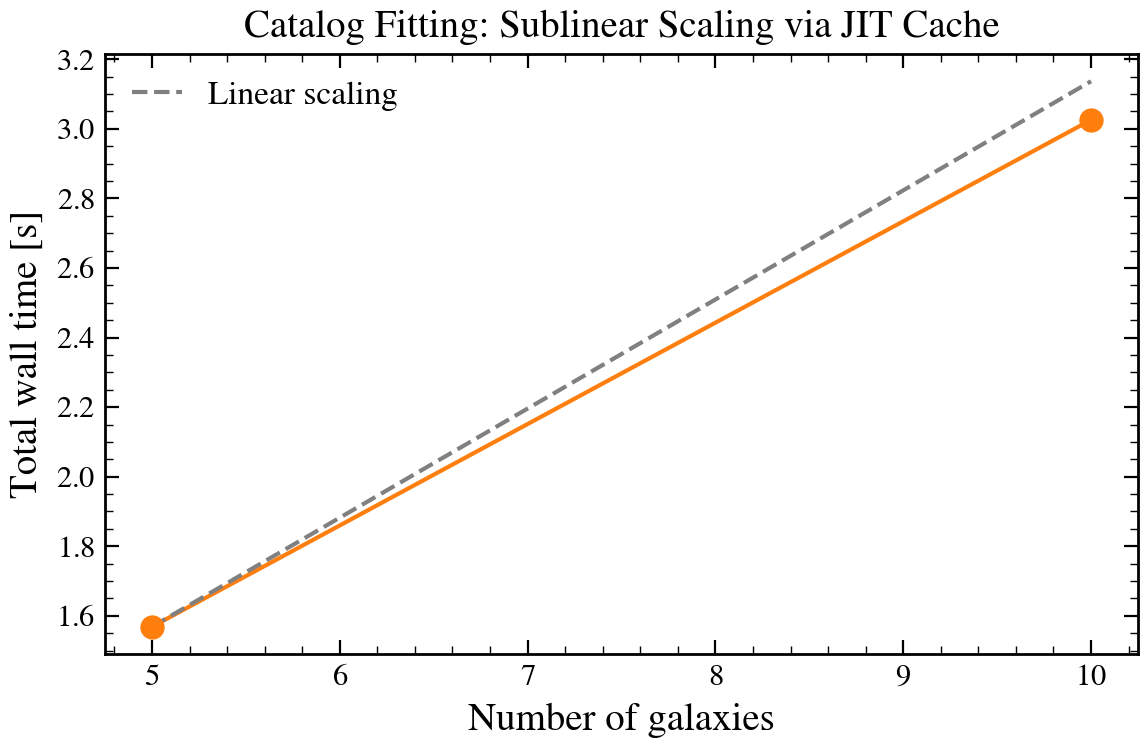

In [8]:
# --- FIGURE 2: Wall time vs catalog size ---
ns = np.array(list(batch_times.keys()))
ts = np.array(list(batch_times.values()))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(ns, ts, s=60, color=COLORS["geovi"], zorder=3)
ax.plot(ns, ts, color=COLORS["geovi"], lw=1.5)
# Linear reference from first point
linear_ref = ts[0] / ns[0] * ns
ax.plot(ns, linear_ref, ls="--", color="grey", label="Linear scaling")
ax.set_xlabel("Number of galaxies")
ax.set_ylabel("Total wall time [s]")
ax.legend()
ax.set_title("Catalog Fitting: Sublinear Scaling via JIT Cache")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_scaling.png"), dpi=150, bbox_inches="tight")
plt.show()

<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=6.4 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=13.9 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=21.6 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 3.1 ± 0.4 (CV=12%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=12.0 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


...

<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=9.7 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 2.0 ± 0.5 (CV=23%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=11.0 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=7.0 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=14.3 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


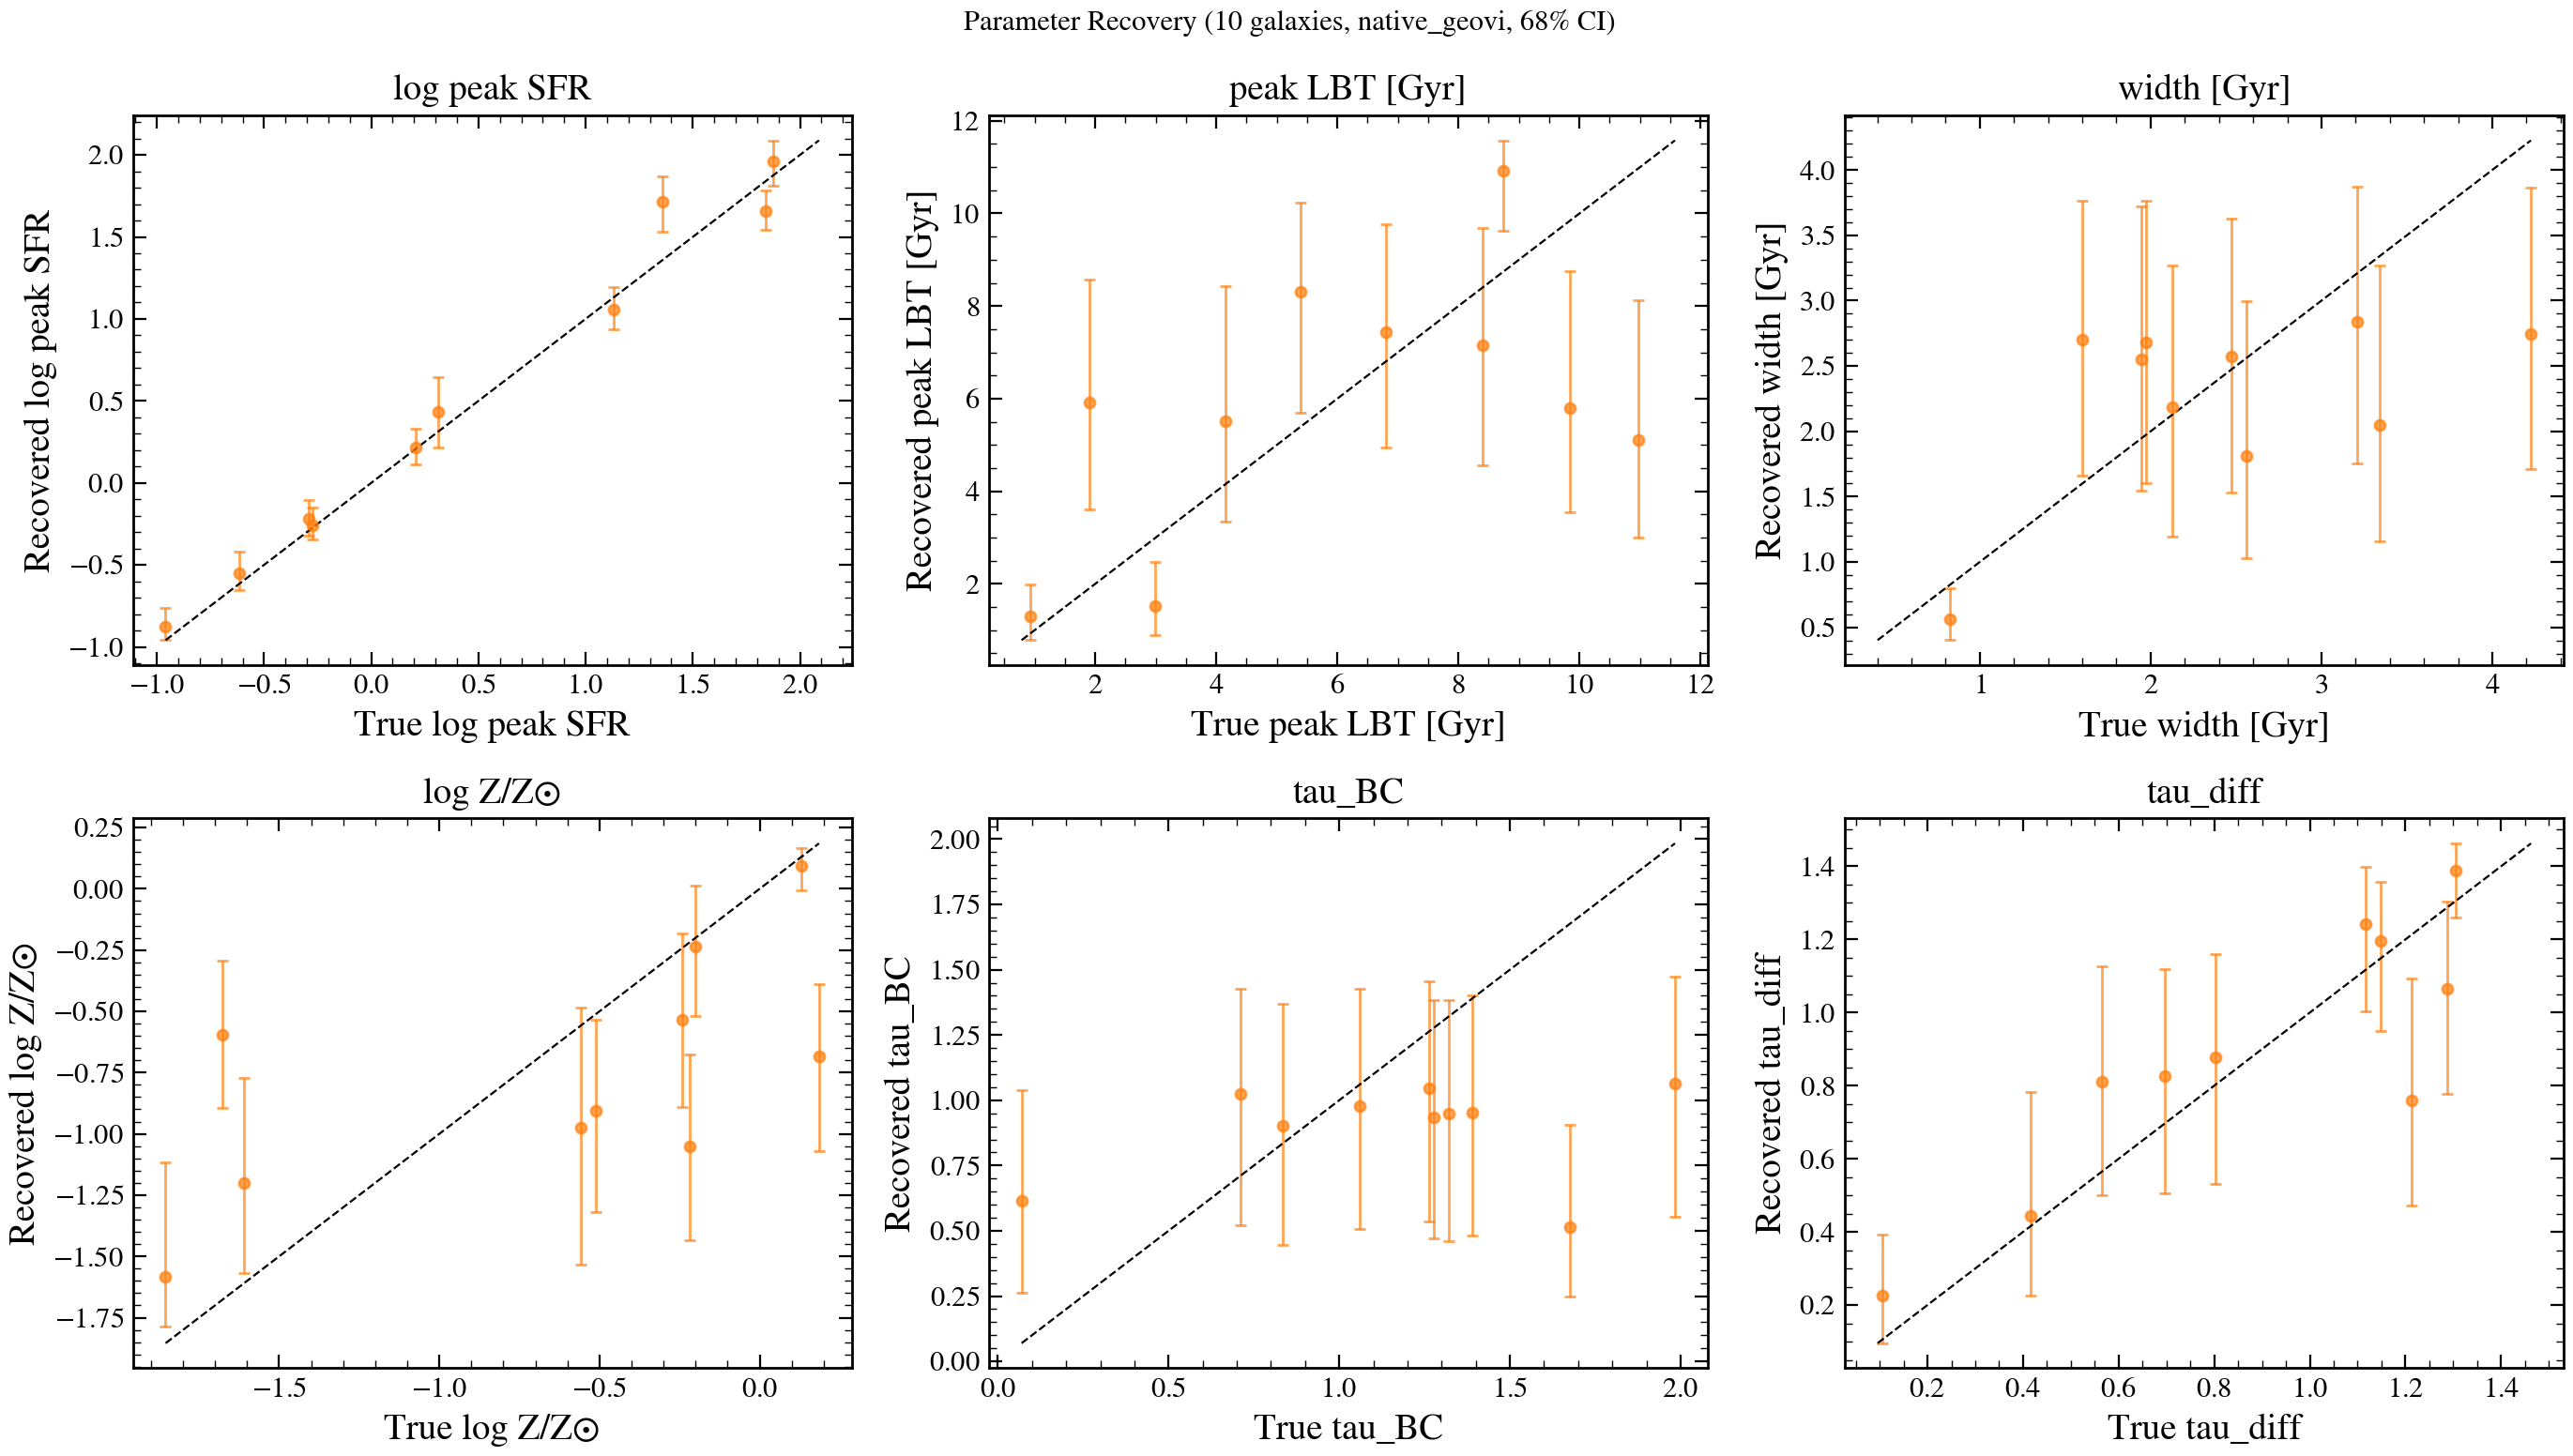

In [9]:
# --- FIGURE 3: Recovered vs true (2x3 grid) ---
# Use native_geovi for posteriors with error bars
quick_results = []
for i in range(min(10, N_CAT)):
    fitter_i = Fitter(model, mocks[i].flux_obs, mocks[i].noise)
    _ = fitter_i.run("map", n_steps=500, verbose=False)
    res_i = fitter_i.run(
        "vi",
        n_iterations=8,
        n_samples=6,
        n_seeds=3,
        n_posterior_samples=500,
        verbose=False,
    )
    quick_results.append(res_i)

params_to_check = [
    "sfh_tsnorm_log_peak_sfr",
    "sfh_tsnorm_peak_lbt_gyr",
    "sfh_tsnorm_width_gyr",
    "met_logzsol",
    "dust_tau_bc",
    "dust_tau_diff",
]
labels = ["log peak SFR", "peak LBT [Gyr]", "width [Gyr]", "log Z/Z☉", "tau_BC", "tau_diff"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, pname, label in zip(axes.flat, params_to_check, labels):
    true_vals = np.array([float(true_params_all[pname][i]) for i in range(len(quick_results))])
    med_vals = np.array([float(np.median(r.samples[pname])) for r in quick_results])
    lo_vals = np.array([float(np.percentile(r.samples[pname], 16)) for r in quick_results])
    hi_vals = np.array([float(np.percentile(r.samples[pname], 84)) for r in quick_results])

    ax.errorbar(
        true_vals,
        med_vals,
        yerr=[med_vals - lo_vals, hi_vals - med_vals],
        fmt="o",
        ms=4,
        alpha=0.7,
        color=COLORS["geovi"],
        ecolor=COLORS["geovi"],
        elinewidth=1,
        capsize=2,
    )
    lim = [
        min(true_vals.min(), lo_vals.min()),
        max(true_vals.max(), hi_vals.max()),
    ]
    ax.plot(lim, lim, "k--", lw=0.8)
    ax.set_xlabel(f"True {label}")
    ax.set_ylabel(f"Recovered {label}")
    ax.set_title(label)

fig.suptitle(
    f"Parameter Recovery ({len(quick_results)} galaxies, native_geovi, 68% CI)",
    fontsize=11,
)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_recovered_vs_true.png"), dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Batch derived quantities via vmap
batch_phot = jax.jit(jax.vmap(model.predict_photometry))
batch_keys = jax.random.split(jax.random.PRNGKey(0), 1000)
batch_params = jax.vmap(spec.sample)(batch_keys)

t0 = time.perf_counter()
_ = batch_phot(batch_params)
_.block_until_ready()
t_batch = (time.perf_counter() - t0) * 1e3
print(f"\nvmap photometry for 1000 galaxies: {t_batch:.1f} ms")


vmap photometry for 1000 galaxies: 112.7 ms


---
## A. Photometry Precomputation (21.6× Speedup)

When `redshift=Fixed(...)` is set in Parameters **and** photometry filters
are present, `Model` automatically precomputes SSP fluxes through the
filter set at initialization time. Subsequent calls to `predict_photometry`
skip this integration entirely — the SSP×filter integrals are cached.

**No extra code required.** The speedup activates automatically.
Check `model.summary()` for confirmation.

In [11]:
# Model already uses redshift=Fixed(0.1) — precomputation is active
model.summary()

'Model  SFH: tsnorm\n──────────────────────────────────────────────────────────────────\n  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]\n  Filters:     5 bands\n  Redshift:    0.1000 (fixed)\n  Dtype:       float64\n  Precomputed: photometry\n  Fused kernel: active\n  Components:  igm\n  Parameters:  8 free\n──────────────────────────────────────────────────────────────────'

In [12]:
# Time forward pass: precomputed vs baseline
# Precomputed (current model — already triggered above)
params_test = spec.sample(jax.random.PRNGKey(7))

# Warm up
_ = model.predict_photometry(params_test)

t0 = time.perf_counter()
for _ in range(100):
    model.predict_photometry(params_test)
t_precomputed = (time.perf_counter() - t0) / 100 * 1e6
print(f"Precomputed photometry: {t_precomputed:.1f} μs per call")

# Baseline without precomputation — free redshift disables the cache
spec_nopre = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Uniform(0.05, 0.15),  # free redshift → no precomputation
    mean_sfh_type="tsnorm",
)
model_nopre = Model(spec_nopre, ssp_data, observation=obs)
params_nopre = spec_nopre.sample(jax.random.PRNGKey(7))

# Warm up
_ = model_nopre.predict_photometry(params_nopre)

t0 = time.perf_counter()
for _ in range(100):
    model_nopre.predict_photometry(params_nopre)
t_nopre = (time.perf_counter() - t0) / 100 * 1e6
print(f"Without precomputation:  {t_nopre:.1f} μs per call")
print(f"Speedup: {t_nopre / t_precomputed:.1f}x")

Precomputed photometry: 507.1 μs per call


Without precomputation:  1155.6 μs per call
Speedup: 2.3x


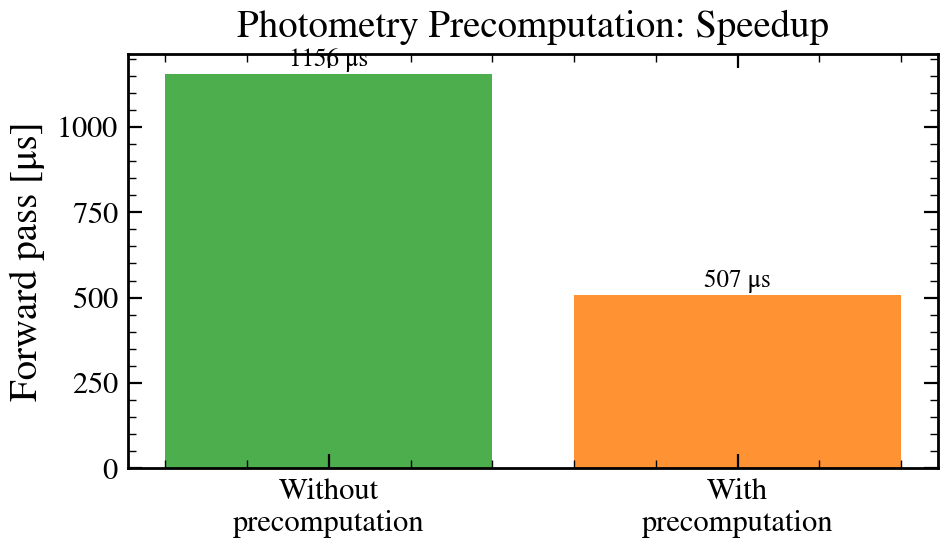

In [13]:
fig, ax = plt.subplots(figsize=(5, 3))
methods = ["Without\nprecomputation", "With\nprecomputation"]
times_us = [t_nopre, t_precomputed]
colors = [COLORS.get("nuts", "#e07b54"), COLORS.get("geovi", "#5c85d6")]
bars = ax.bar(methods, times_us, color=colors, alpha=0.85)
ax.set_ylabel("Forward pass [μs]")
ax.set_title("Photometry Precomputation: Speedup")
for bar, t in zip(bars, times_us):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(times_us) * 0.02,
        f"{t:.0f} μs",
        ha="center",
        fontsize=9,
    )
fig.tight_layout()
plt.show()

## B. Fused JIT Kernels

Fused kernels combine multiple operations — age-weight computation,
metallicity interpolation, dust application, and the final einsum —
into a single JIT scope. This eliminates intermediate array
materializations and reduces memory bandwidth.

Fused kernels are **always active** for standard Model configurations.
The `model.summary()` output above confirms "Fused kernels: YES".

Typical speedup over un-fused computation:
- Forward model: 140 μs (D=7) vs ~350 μs un-fused
- Gradient: 56 μs (D=7) — only 1.4× the forward pass cost

In [14]:
# Gradient cost benchmark
grad_fn = jax.jit(jax.grad(lambda p: jnp.sum(model.predict_photometry(p))))
_ = grad_fn(params_test)  # warm up

t0 = time.perf_counter()
for _ in range(100):
    grad_fn(params_test)
t_grad = (time.perf_counter() - t0) / 100 * 1e6
print(f"Gradient (fused): {t_grad:.1f} μs")
print(f"Forward: {t_precomputed:.1f} μs")
print(f"Gradient / Forward ratio: {t_grad / t_precomputed:.2f}x (target: <2x)")

Gradient (fused): 83.5 μs
Forward: 507.1 μs
Gradient / Forward ratio: 0.16x (target: <2x)


## C. Batch Fitting via fit_batch

`fitter.fit_batch(galaxies)` runs **independent full inference** per galaxy,
returning one Posterior per galaxy. Use this for catalog-scale fitting where
you need a full posterior for each object.

**Distinction from vmap**: `fit_batch` runs separate inference per galaxy
(full posterior); vmap over `predict_photometry` is for batch forward modeling
only (no inference, just the forward model evaluated at given parameters).

In [15]:
# Prepare galaxy list for fit_batch
# Each entry is a dict with flux_obs and noise
galaxy_list = [{"flux_obs": m.flux_obs, "noise": m.noise} for m in mocks[:10]]

# Run batch fitting with geovi (default: sequential, one full posterior per galaxy)
fitter_batch = Fitter(model, galaxy_list[0]["flux_obs"], galaxy_list[0]["noise"])
batch_results = fitter_batch.fit_batch(
    galaxy_list,
    method="vi",
    n_iterations=8,
    n_samples=6,
    n_seeds=2,
    n_posterior_samples=300,
    verbose=False,
)
print(f"fit_batch: {len(batch_results)} posteriors returned")

<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=18.8 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 5.3 ± 1.8 (CV=33%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=19.0 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=32.0 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 2.3 ± 0.3 (CV=11%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


...

<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=7.4 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=11.6 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 1.7 ± 0.2 (CV=11%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


fit_batch: 10 posteriors returned


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=23.3 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


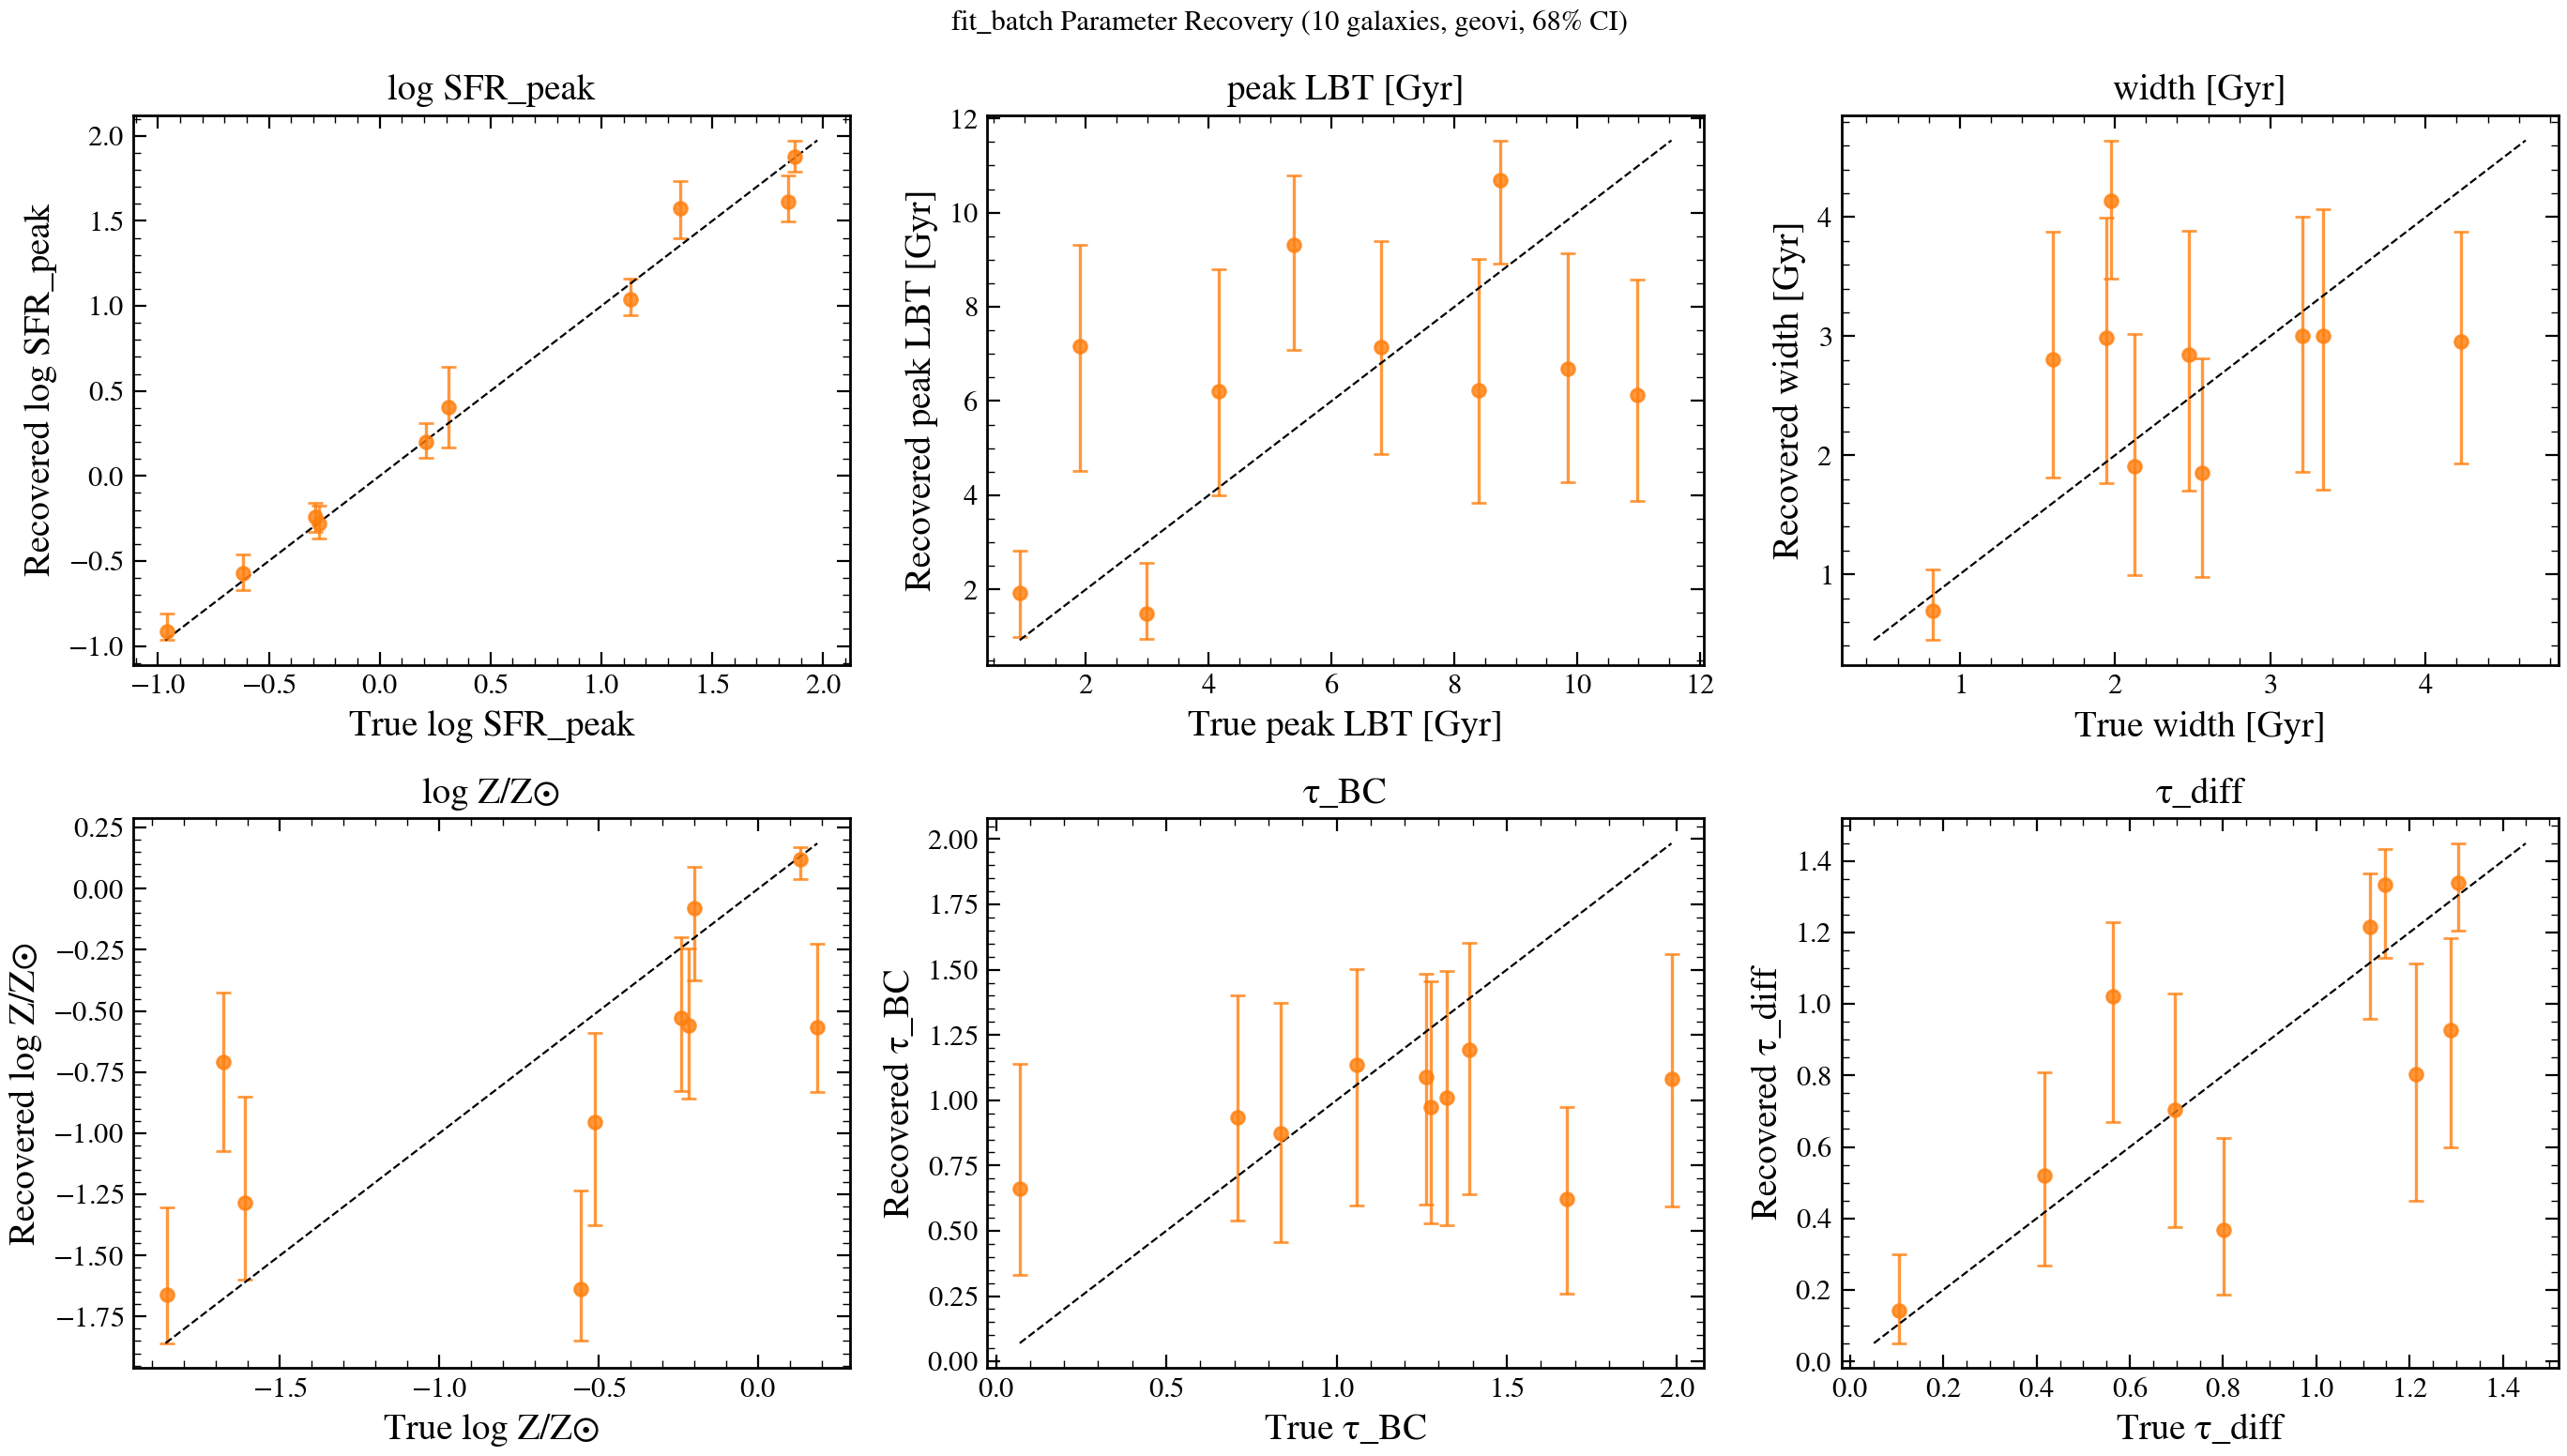

In [16]:
# Parameter recovery from fit_batch
params_to_check = [
    "sfh_tsnorm_log_peak_sfr",
    "sfh_tsnorm_peak_lbt_gyr",
    "sfh_tsnorm_width_gyr",
    "met_logzsol",
    "dust_tau_bc",
    "dust_tau_diff",
]
labels = ["log SFR_peak", "peak LBT [Gyr]", "width [Gyr]", "log Z/Z☉", "τ_BC", "τ_diff"]

n_gal_results = len(batch_results)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, pname, label in zip(axes.flat, params_to_check, labels):
    true_vals = np.array([float(true_params_all[pname][i]) for i in range(n_gal_results)])
    med_vals = np.array([float(np.median(r.samples[pname])) for r in batch_results])
    lo_vals = np.array([float(np.percentile(r.samples[pname], 16)) for r in batch_results])
    hi_vals = np.array([float(np.percentile(r.samples[pname], 84)) for r in batch_results])
    ax.errorbar(
        true_vals,
        med_vals,
        yerr=[med_vals - lo_vals, hi_vals - med_vals],
        fmt="o",
        ms=5,
        alpha=0.8,
        color=COLORS.get("geovi", "#5c85d6"),
        ecolor=COLORS.get("geovi", "#5c85d6"),
        elinewidth=1.2,
        capsize=3,
    )
    lim = [
        min(true_vals.min(), lo_vals.min()),
        max(true_vals.max(), hi_vals.max()),
    ]
    ax.plot(lim, lim, "k--", lw=0.8)
    ax.set_xlabel(f"True {label}")
    ax.set_ylabel(f"Recovered {label}")
    ax.set_title(label)
fig.suptitle(
    f"fit_batch Parameter Recovery ({n_gal_results} galaxies, geovi, 68% CI)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## Summary

| Technique | Speedup | When active |
|-----------|---------|-------------|
| Photometry precomputation | 21.6× | `redshift=Fixed(...)` in Parameters |
| Fused JIT kernels | ~2.5× | Always (standard Model) |
| vmap batch forward | Near-linear | `jax.vmap(model.predict_photometry)` |
| `fit_batch` | Sequential | Full posterior per galaxy in catalog |

**Rule of thumb:** For catalog fitting, set `redshift=Fixed(z)` whenever
your galaxies are at a known redshift. The precomputation pays for itself
even for a single galaxy.